To do today:
1 - finish the code for the scaling wrt model parameters and data
2 - generate the first figure of the paper.
3 - rewrite the section for the wave equation.
4 - prepare some figures for the meeting. 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import random
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
SEED = 12345

# ---- (A) Python / NumPy / PyTorch seeds ----
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
fromjoint = False   # True: train T(u,y;y_dag). False: train T(u;y_dag) using prior loss.
epochs = 60
batch_size=1000
ndata=600000

run_tag = "joint" if fromjoint else "prior"


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Preprocessing the data

In [5]:
# Paths to data
data_dir = "./../../Data/Experiment1"
u_path = os.path.join(data_dir, "samples_u.npy")
y_path = os.path.join(data_dir, "samples_y.npy")

# Load data
u = np.load(u_path)[:ndata]
y = np.load(y_path)[:ndata]

# Sanity check
print(f"Loaded {len(u)} samples.")
print(f"u shape: {u.shape}, y shape: {y.shape}")
print(f"First few (u, y) pairs:")
for i in range(5):
    print(f"u = {u[i]:.4f}, y = {y[i]:.4f}")
u_train_test, u_infer, y_train_test, y_infer = train_test_split(u, y, test_size=0.5 , random_state=SEED, shuffle=True)

# Split into training and testing
u_train, u_test, y_train, y_test = train_test_split(u_train_test, y_train_test, test_size=0.1, random_state=SEED+1, shuffle=True)

print("Size of training set:", len(u_train))


Loaded 6000 samples.
u shape: (6000,), y shape: (6000,)
First few (u, y) pairs:
u = 0.4967, y = 1.3114
u = -0.1383, y = -0.4776
u = 0.6477, y = 0.5488
u = 1.5230, y = 0.8399
u = -0.2342, y = -0.2550
Size of training set: 2700


In [6]:
class IndexedJointDataset(torch.utils.data.Dataset):
    def __init__(self, u, y):
        self.u = torch.tensor(u, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.y[idx], idx


## Defining the loss function 

In [7]:
def energy_distance_loss(model, u_batch, y_batch):
    
    """
    Computes the empirical energy-distance-based loss:
        L(θ) = Accuracy Term - Repulsion Term

    Args:
        model      : neural network implementing T(u, y; y^dag)
        u_batch    : Tensor of shape (B,), batch of u samples
        y_batch    : Tensor of shape (B,), corresponding y values
        Potential inputs for upscaling:
        indices    : Tensor of shape (B,), indices of the batch samples in the full dataset
        full_u     : Tensor of shape (N,), all training u values
        full_y     : Tensor of shape (N,), all training y values

    Returns:
        Scalar loss (torch.float32)
    """
    device = u_batch.device  
    B = u_batch.shape[0] # Batch size
    # using vectorization to avoid loops:
    # Generate all (i, j) pairs for accuracy term,
    u_i = u_batch.unsqueeze(1).expand(B, B).reshape(-1).to(device)
    y_i = y_batch.unsqueeze(1).expand(B, B).reshape(-1).to(device)
    y_j = y_batch.unsqueeze(0).expand(B, B).reshape(-1).to(device)
    u_j = u_batch.unsqueeze(0).expand(B, B).reshape(-1).to(device)

    # print(u_i,y_i,y_j)
    acc_pred = model(u_i, y_i, y_j)
    # print(acc_pred)

    acc_matrix = torch.abs(acc_pred - u_j).view(B, B)
    acc_matrix.fill_diagonal_(0.0) # removing the terms on the diagonal
    acc_loss = acc_matrix.sum() / (B * (B - 1))

    # === Repulsion term ===
    # For each y_k (k=0,...,B-1), we compute T(u_i, y_i; y_k)
    # Shape: (B, B)
    y_k_matrix = y_batch.view(1, B).expand(B, B).to(device)  # shape (B, B)
    u_i_matrix = u_batch.view(B, 1).expand(B, B).to(device)  # shape (B, B)
    y_i_matrix = y_batch.view(B, 1).expand(B, B).to(device)  # shape (B, B)

    # print("y_k_matrix.reshape(-1):", y_k_matrix.reshape(-1))
    # print("u_i_matrix.reshape(-1):", u_i_matrix.reshape(-1))
    # print("y_i_matrix.reshape(-1):", y_i_matrix.reshape(-1))
    # Evaluate model: shape (B, B)
    T_out = model(u_i_matrix.reshape(-1), y_i_matrix.reshape(-1), y_k_matrix.reshape(-1)) # This one has N^2 members
    # print("T_out:", T_out)
    T_out = T_out.view(B, B)  # shape (B, B): rows = inputs, cols = different y_k
    # print("T_out reshaped:", T_out)
    # Compute pairwise distances between rows: |T_i - T_j| for each y_k (column)
    # Result: matrix of shape (B, B) for each column → stack into (B, B, B)
    diffs = T_out.unsqueeze(0) - T_out.unsqueeze(1)  # shape (B, B, B)
    dists = torch.abs(diffs)
    idx = torch.arange(B, device=device)

    # remove i=j
    dists[idx, idx, :] = 0

    # remove i=k  (for each k, kill row i=k in slice k)
    dists[:, idx, idx] = 0   # this targets dists[j, i=idx, k=idx]

    # remove j=k  (for each k, kill col j=k in slice k)
    dists[idx, :, idx] = 0   # this targets dists[j=idx, i, k=idx]


    # print("T_out_unsqueeze(0)",T_out.unsqueeze(0))
    # print("T_out_unsqueeze(1)",T_out.unsqueeze(1))
    # print("diffs:", diffs)
    # print("diffs shape:", diffs.shape)

    # Average over all (i, j) including diagonals, then correct
    repulsion_per_k = dists.sum(dim=(0, 1)) / ((B - 1) * (B - 2))  # shape (B,)
    repulsion_loss = repulsion_per_k.mean()

    # print("u_i:", u_i)
    # print("y_i:", y_i)
    # print("y_j:", y_j)
    # print("u_j:", u_j)
    # print("pred:", acc_loss)
    # print("repulsion_loss:", repulsion_loss)
    return 2 * acc_loss - repulsion_loss


In [8]:
def energy_distance_loss_fromprior(model, u_batch, y_batch):
    
    """
    Computes the empirical energy-distance-based loss:
        L(θ) = Accuracy Term - Repulsion Term

    Args:
        model      : neural network implementing T(u, y; y^dag)
        u_batch    : Tensor of shape (B,), batch of u samples
        y_batch    : Tensor of shape (B,), corresponding y values
        Potential inputs for upscaling:
        indices    : Tensor of shape (B,), indices of the batch samples in the full dataset
        full_u     : Tensor of shape (N,), all training u values
        full_y     : Tensor of shape (N,), all training y values

    Returns:
        Scalar loss (torch.float32)
    """
    device = u_batch.device  
    B = u_batch.shape[0] # Batch size
    # using vectorization to avoid loops:
    # Generate all (i, j) pairs for accuracy term,
    u_i = u_batch.unsqueeze(1).expand(B, B).reshape(-1).to(device)
    # y_i = y_batch.unsqueeze(1).expand(B, B).reshape(-1).to(device)
    y_j = y_batch.unsqueeze(0).expand(B, B).reshape(-1).to(device)
    u_j = u_batch.unsqueeze(0).expand(B, B).reshape(-1).to(device)

    # print(u_i,y_i,y_j)
    acc_pred = model(u_i, y_j)
    # print(acc_pred)

    acc_matrix = torch.abs(acc_pred - u_j).view(B, B)
    acc_matrix.fill_diagonal_(0.0) # removing the terms on the diagonal
    acc_loss = acc_matrix.sum() / (B * (B - 1))

    # === Repulsion term ===
    # For each y_k (k=0,...,B-1), we compute T(u_i, y_i; y_k)
    # Shape: (B, B)
    y_k_matrix = y_batch.view(1, B).expand(B, B).to(device)  # shape (B, B)
    u_i_matrix = u_batch.view(B, 1).expand(B, B).to(device)  # shape (B, B)
    # y_i_matrix = y_batch.view(B, 1).expand(B, B).to(device)  # shape (B, B)

    # print("y_k_matrix.reshape(-1):", y_k_matrix.reshape(-1))
    # print("u_i_matrix.reshape(-1):", u_i_matrix.reshape(-1))
    # print("y_i_matrix.reshape(-1):", y_i_matrix.reshape(-1))
    # Evaluate model: shape (B, B)
    T_out = model(u_i_matrix.reshape(-1), y_k_matrix.reshape(-1)) # This one has N^2 members
    # print("T_out:", T_out)
    T_out = T_out.view(B, B)  # shape (B, B): rows = inputs, cols = different y_k
    # print("T_out reshaped:", T_out)
    # Compute pairwise distances between rows: |T_i - T_j| for each y_k (column)
    # Result: matrix of shape (B, B) for each column → stack into (B, B, B)
    diffs = T_out.unsqueeze(0) - T_out.unsqueeze(1)  # shape (B, B, B)
    dists = torch.abs(diffs)
    idx = torch.arange(B, device=device)

    # remove i=j
    dists[idx, idx, :] = 0

    # remove i=k  (for each k, kill row i=k in slice k)
    dists[:, idx, idx] = 0   # this targets dists[j, i=idx, k=idx]

    # remove j=k  (for each k, kill col j=k in slice k)
    dists[idx, :, idx] = 0   # this targets dists[j=idx, i, k=idx]


    # print("T_out_unsqueeze(0)",T_out.unsqueeze(0))
    # print("T_out_unsqueeze(1)",T_out.unsqueeze(1))
    # print("diffs:", diffs)
    # print("diffs shape:", diffs.shape)

    # Average over all (i, j) including diagonals, then correct
    repulsion_loss = dists.sum() / (B * (B - 1) * (B - 2))

    # print("u_i:", u_i)
    # print("y_i:", y_i)
    # print("y_j:", y_j)
    # print("u_j:", u_j)
    # print("pred:", acc_loss)
    # print("repulsion_loss:", repulsion_loss)
    return 2 * acc_loss - repulsion_loss


## Testing implementation of the loss function
Here I write a test to check if the loss function is implemented correctly

In [9]:
# class DummyModel(torch.nn.Module):
#     def forward(self, u, y, y_dag):
#         # Return a known, simple transformation for debugging
#         return u + y*y_dag
# u_batch = torch.tensor([1.0, 2.0])
# y_batch = torch.tensor([10.0, 20.0])
# energy_distance_loss(DummyModel(), u_batch, y_batch)


## Defining the model


In [10]:
class MLP_T(nn.Module):
    def __init__(self, fromjoint=True, hidden_dim=150, output_dim=1, num_layers=8):
        super().__init__()
        self.fromjoint = fromjoint
        input_dim = 3 if fromjoint else 2

        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.GELU())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.GELU())

        self.network = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, output_dim),
        )

    def forward(self, u, y_or_y_dag, y_dag=None):
        """
        If fromjoint=True: forward(u, y, y_dag)
        If fromjoint=False: forward(u, y_dag)   (y_dag argument ignored)
        """
        if self.fromjoint:
            assert y_dag is not None, "fromjoint=True requires y_dag"
            x = torch.stack([u, y_or_y_dag, y_dag], dim=-1)
        else:
            # here y_or_y_dag is y_dag
            x = torch.stack([u, y_or_y_dag], dim=-1)

        features = self.network(x)
        out = self.head(features).squeeze(-1)
        return u + out

In [11]:
loss_fn = energy_distance_loss if fromjoint else energy_distance_loss_fromprior

## Training


/resnick/groups/astuart/hkaveh/soft/miniconda3/envs/chaoslearn/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/60 — Train Loss: 1.113962 — Val Loss: 1.148799 — LR: 1.00e-03
Epoch 2/60 — Train Loss: 1.047894 — Val Loss: 1.101393 — LR: 1.00e-03
Epoch 3/60 — Train Loss: 1.035902 — Val Loss: 1.098557 — LR: 1.00e-03
Epoch 4/60 — Train Loss: 1.030884 — Val Loss: 1.093771 — LR: 1.00e-03
Epoch 5/60 — Train Loss: 1.019545 — Val Loss: 1.080529 — LR: 1.00e-03
Epoch 6/60 — Train Loss: 1.017071 — Val Loss: 1.097497 — LR: 1.00e-03
Epoch 7/60 — Train Loss: 1.023179 — Val Loss: 1.082814 — LR: 1.00e-03
Epoch 8/60 — Train Loss: 1.018185 — Val Loss: 1.079567 — LR: 1.00e-03
Epoch 9/60 — Train Loss: 1.016110 — Val Loss: 1.088158 — LR: 1.00e-03
Epoch 10/60 — Train Loss: 1.005973 — Val Loss: 1.078225 — LR: 1.00e-03
Epoch 11/60 — Train Loss: 1.023675 — Val Loss: 1.093208 — LR: 1.00e-03
Epoch 12/60 — Train Loss: 1.010797 — Val Loss: 1.073387 — LR: 1.00e-03
Epoch 13/60 — Train Loss: 1.005774 — Val Loss: 1.071873 — LR: 1.00e-03
Epoch 14/60 — Train Loss: 1.002376 — Val Loss: 1.083258 — LR: 1.00e-03
Epoch 15/60 — T

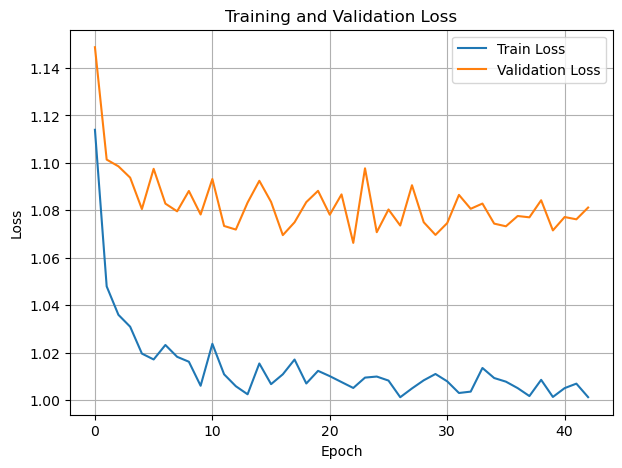

Best model loaded with validation loss: 1.0662418603897095  | mode: prior


/tmp/ipykernel_503405/277478808.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


In [12]:
train_dataset = IndexedJointDataset(u_train, y_train)
g = torch.Generator()
g.manual_seed(SEED)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g
)


model = MLP_T(fromjoint=fromjoint).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

ckpt_path = f"best_model_{run_tag}.pt"

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,      # multiply lr by this
    patience=10,      # epochs w/o val improvement before reducing
    threshold=1e-4,
    min_lr=1e-6,
    verbose=True
)

# ------------------------------
# Training loop with validation, tracking, and early stopping
# ------------------------------
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience, trigger_times = 20, 0  # stop if no improvement for 10 epochs

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    for u_batch, y_batch, idx_batch in train_loader:
        u_batch, y_batch = u_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model, u_batch, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss_total = 0.0
        val_loader = torch.utils.data.DataLoader(
            IndexedJointDataset(u_test, y_test),
            batch_size=batch_size,
            shuffle=False,
        )
        for u_val, y_val, _ in val_loader:
            u_val, y_val = u_val.to(device), y_val.to(device)
            val_loss_total += loss_fn(model, u_val, y_val).item()
        val_loss = val_loss_total / len(val_loader)
        val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.6f} — Val Loss: {val_loss:.6f} — LR: {current_lr:.2e}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# ------------------------------
# Plot losses
# ------------------------------
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# Load best model
# ------------------------------
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print("Best model loaded with validation loss:", best_val_loss, " | mode:", run_tag)

## Inference


In [22]:
def sample_operator(model, u_source, y_source, y_dag_fixed, num_samples=None, device=None):
    """
    Draw samples from learned operator.
    - fromjoint=True: uses (u,y) pairs from joint + fixed y_dag
    - fromjoint=False: uses u from prior (provided as u_source) + fixed y_dag
    """
    model.eval()
    with torch.no_grad():
        if device is None:
            device = next(model.parameters()).device

        if num_samples is None:
            num_samples = len(u_source)

        u_in = torch.tensor(u_source[:num_samples], dtype=torch.float32, device=device)

        if getattr(model, "fromjoint", True):
            y_in = torch.tensor(y_source[:num_samples], dtype=torch.float32, device=device)
            y_dag = torch.full_like(u_in, y_dag_fixed, device=device)
            u_pred = model(u_in, y_in, y_dag)
        else:
            y_dag = torch.full_like(u_in, y_dag_fixed, device=device)
            u_pred = model(u_in, y_dag)

        return u_pred.cpu().numpy()

In [23]:
def unnormalized_log_posterior(u, y_dag):
    return -0.5 * (y_dag - u**2)**2 - 0.5 * u**2
def unnormalized_posterior(u, y_dag):
    return np.exp(unnormalized_log_posterior(u, y_dag))


In [24]:
from matplotlib import rcParams

# Optional: Use LaTeX-style fonts
# rcParams['text.usetex'] = False  # Set to True if you have LaTeX installed
# rcParams['font.family'] = 'serif'
# rcParams['font.serif'] = ['Computer Modern']  # or ['Times New Roman'] or ['Palatino']

def plot_posterior_comparison_exact(u_pred_samples, y_dag_fixed, u_range=(-5, 5)):
    u_grid = np.linspace(u_range[0], u_range[1], 1000)
    p_true = unnormalized_posterior(u_grid, y_dag_fixed)
    p_true /= np.trapz(p_true, u_grid)  # Normalize so it integrates to 1

    plt.figure(figsize=(7, 5))
    
    # Plot exact posterior
    plt.plot(u_grid, p_true, label='Exact posterior', linewidth=2)
    
    # Plot learned operator samples
    plt.hist(u_pred_samples, bins=50, alpha=0.5, density=True, label='Learned T samples')

    plt.title(rf'Posterior $\mathbb{{P}}(u \mid y={y_dag_fixed})$')
    plt.xlabel('u')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_503405/1580224885.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_true /= np.trapz(p_true, u_grid)  # Normalize so it integrates to 1


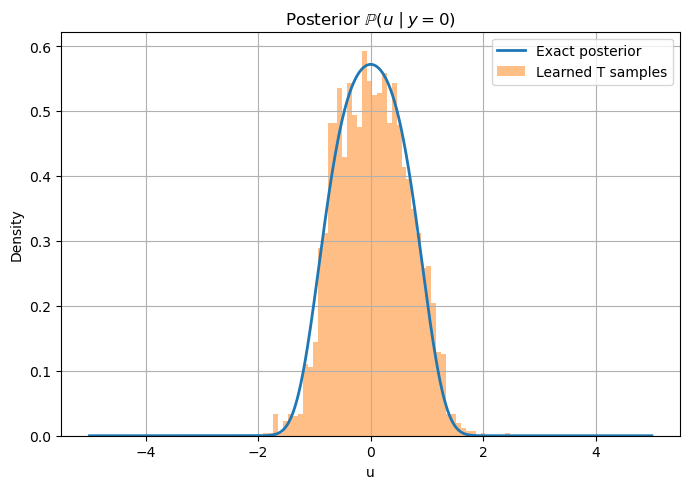

In [25]:
# Choose a fixed y^dagger value to test
y_dag_fixed = 0
# Sample from learned operator
u_pred_samples_0 = sample_operator(model, u_infer, y_infer, y_dag_fixed)
plot_posterior_comparison_exact(u_pred_samples_0, y_dag_fixed)

/tmp/ipykernel_503405/1580224885.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_true /= np.trapz(p_true, u_grid)  # Normalize so it integrates to 1


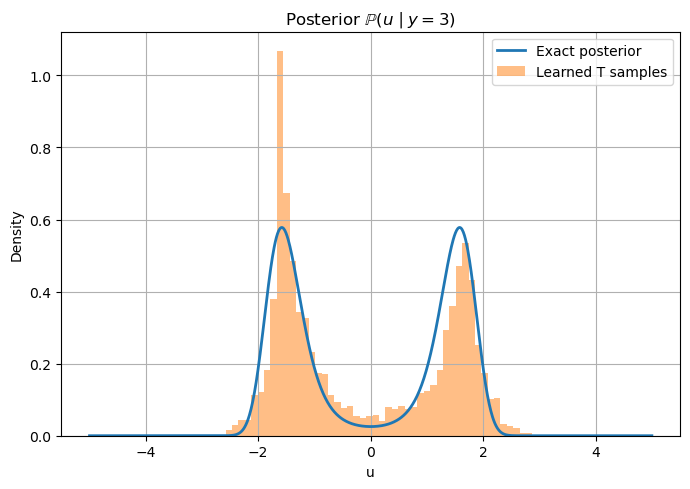

In [26]:
# Choose a fixed y^dagger value to test
y_dag_fixed = 3
# Sample from learned operator
u_pred_samples_3 = sample_operator(model, u_infer, y_infer, y_dag_fixed)
plot_posterior_comparison_exact(u_pred_samples_3, y_dag_fixed)

/tmp/ipykernel_503405/1580224885.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_true /= np.trapz(p_true, u_grid)  # Normalize so it integrates to 1


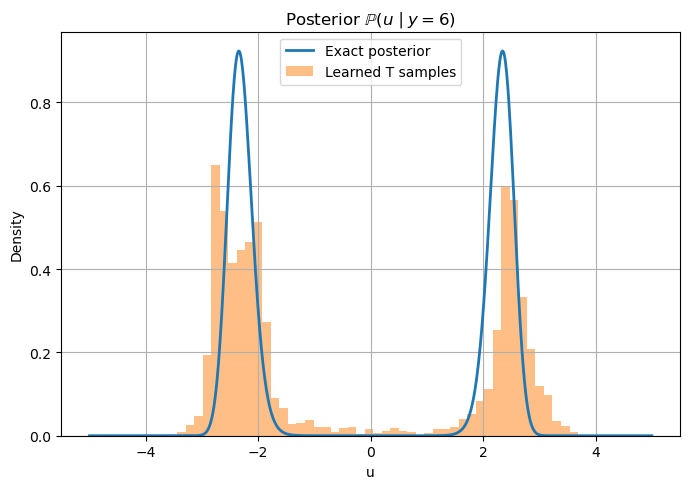

In [27]:
# Choose a fixed y^dagger value to test
y_dag_fixed = 6
# Sample from learned operator
u_pred_samples_6 = sample_operator(model, u_infer, y_infer, y_dag_fixed)
plot_posterior_comparison_exact(u_pred_samples_6, y_dag_fixed)

/tmp/ipykernel_503405/1580224885.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_true /= np.trapz(p_true, u_grid)  # Normalize so it integrates to 1


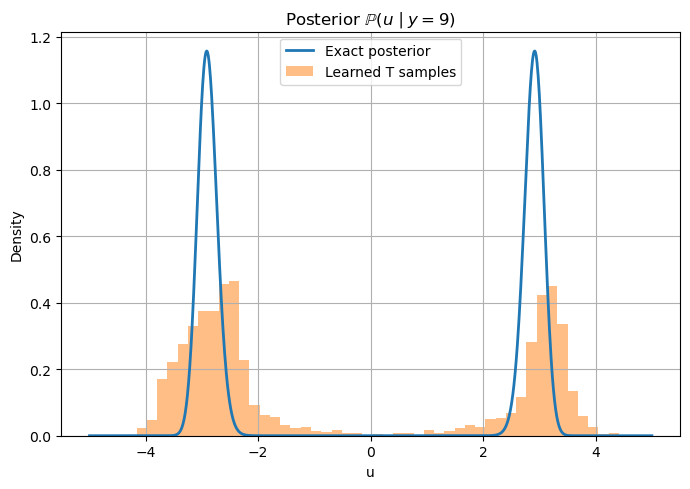

In [28]:
# Choose a fixed y^dagger value to test
y_dag_fixed = 9
# Sample from learned operator
u_pred_samples_9 = sample_operator(model, u_infer, y_infer, y_dag_fixed)
plot_posterior_comparison_exact(u_pred_samples_9, y_dag_fixed)

In [29]:
# from matplotlib import rcParams

# # Optional: Use LaTeX-style fonts
# # Set very large fonts for presentation
# rcParams['font.size'] = 16            # Base font size
# rcParams['axes.titlesize'] = 18       # Title font size
# rcParams['axes.labelsize'] = 18       # Axis label font size
# rcParams['xtick.labelsize'] = 14      # X tick label size
# rcParams['ytick.labelsize'] = 14      # Y tick label size
# rcParams['legend.fontsize'] = 14      # Legend font size
# rcParams['font.family'] = 'serif'

# def plot_posterior_exact(u_pred_samples, y_dag_fixed, u_range=(-5, 5)):
#     u_grid = np.linspace(u_range[0], u_range[1], 1000)
#     p_true = unnormalized_posterior(u_grid, y_dag_fixed)
#     p_true /= np.trapz(p_true, u_grid)  # Normalize so it integrates to 1

#     plt.figure(figsize=(7, 5))
    
#     # Plot exact posterior
#     plt.plot(u_grid, p_true, label='Exact posterior', linewidth=2)
    
#     # Plot learned operator samples
#     # plt.hist(u_pred_samples, bins=50, alpha=0.5, density=True, label='Learned T samples')

#     plt.ylabel(rf'Posterior $\mathbb{{P}}(u \mid y={y_dag_fixed})$')
#     plt.xlabel('u')
#     plt.tight_layout()
#     # 
#     plt.savefig("./../../Figs/Experiment1/exactposterior.png",dpi=300)
#     plt.show()


In [21]:
# plot_posterior_exact(u_pred_samples, y_dag_fixed, u_range=(-5, 5))

In [30]:
from scipy.stats import gaussian_kde

def plot_three_posteriors_line(
    model, u_infer, y_infer,
    y_values=(0, 3, 6),
    u_range=(-5, 5),
    save_path=f"./../../Figs/Experiment1/three_posteriors_{run_tag}.png"
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, y_dag_fixed in zip(axes, y_values):

        # ---- Exact posterior ----
        u_grid = np.linspace(u_range[0], u_range[1], 1000)
        p_true = unnormalized_posterior(u_grid, y_dag_fixed)
        p_true /= np.trapz(p_true, u_grid)

        # ---- Learned samples ----
        u_pred = sample_operator(model, u_infer, y_infer, y_dag_fixed)

        kde = gaussian_kde(u_pred)
        p_learned = kde(u_grid)

        if getattr(model, "fromjoint", True):   # or use the outer-scope `fromjoint`
            learned_label = rf"$T_\theta(\cdot,\cdot; y^\dagger={y_dag_fixed})_\#\,\gamma$"
        else:
            learned_label = rf"$T_\theta(\cdot; y^\dagger={y_dag_fixed})_\#\,\rho$"
        # ---- Plot ----
        ax.plot(
            u_grid,
            p_true,
            linewidth=3,
            label=rf"$\pi(u \mid y^\dagger={y_dag_fixed})$"
        )
        ax.plot(
            u_grid,
            p_learned,
            linestyle="--",
            linewidth=3,
            label=learned_label
        )

        # ax.set_title(rf"$y={y_dag_fixed}$")
        ax.set_xlabel("u")
        ax.set_ylabel("Density")
        # ax.grid(True)
    axes[0].set_ylim(0, 0.6)
    axes[1].set_ylim(0, 0.6)
    axes[2].set_ylim(0, 0.6)
    
    axes[0].legend(fontsize=10, frameon=False, loc="upper right")
    axes[1].legend(fontsize=10, frameon=False, loc="upper right")
    axes[2].legend(fontsize=10, frameon=False, loc="upper right")


    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_503405/2436871048.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_true /= np.trapz(p_true, u_grid)


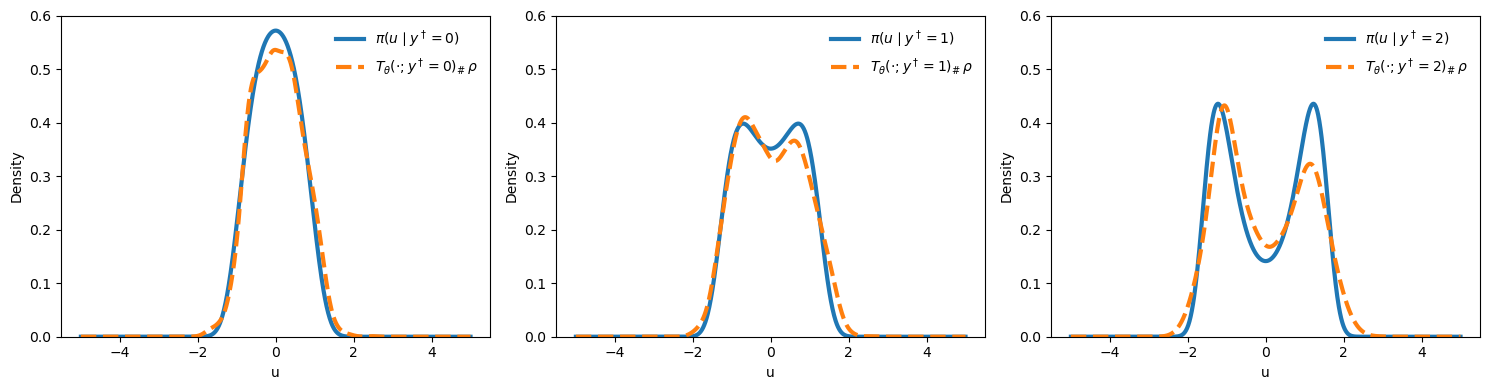

In [31]:
plot_three_posteriors_line(
    model,
    u_infer,
    y_infer,
    y_values=(0, 1, 2)
)

In [48]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

def plot_four_posteriors_two_rows(
    model, u_infer, y_infer,
    y_values=(-1, 0, 1, 2),
    u_range=(-5, 5),
    save_path=f"./../../Figs/Experiment1/four_posteriors_two_rows_{run_tag}.png"
):
    """
    Plot exact posterior and learned pushforward posterior
    for four y^\dagger values in increasing order, arranged in two rows.
    """

    y_values = tuple(sorted(y_values))

    fig, axes = plt.subplots(2, 2, figsize=(7.4, 5), sharex=True, sharey=True)
    axes = axes.ravel()

    u_grid = np.linspace(u_range[0], u_range[1], 1000)

    for ax, y_dag_fixed in zip(axes, y_values):

        # ---- Exact posterior ----
        p_true = unnormalized_posterior(u_grid, y_dag_fixed)
        p_true /= np.trapz(p_true, u_grid)

        # ---- Learned samples ----
        u_pred = sample_operator(model, u_infer, y_infer, y_dag_fixed)

        kde = gaussian_kde(u_pred)
        p_learned = kde(u_grid)

        # ---- Legend labels ----
        exact_label = rf"$\pi(u \mid y^\dagger={y_dag_fixed})$"

        if getattr(model, "fromjoint", True):
            learned_label = rf"$T_\theta(\cdot,\cdot\,; y^\dagger={y_dag_fixed})_\#\gamma$"
        else:
            learned_label = rf"$T_\theta(\cdot\,; y^\dagger={y_dag_fixed})_\#\rho$"

        # ---- Plot ----
        ax.plot(
            u_grid,
            p_true,
            linewidth=3,
            label=exact_label
        )

        ax.plot(
            u_grid,
            p_learned,
            linestyle="--",
            linewidth=3,
            label=learned_label
        )

        ax.set_xlabel(r"$u$", fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.tick_params(axis="both", labelsize=8)

        ax.legend(fontsize=8, frameon=False, loc="upper right")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_503405/2277528699.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_true /= np.trapz(p_true, u_grid)


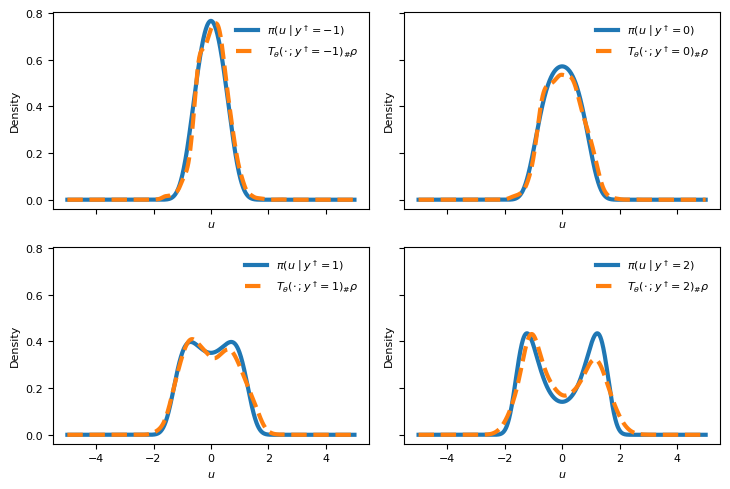

In [49]:
plot_four_posteriors_two_rows(
    model,
    u_infer,
    y_infer,
    y_values=(-1, 0, 1, 2),
    u_range=(-5, 5)
)